## **项目:电商用户行为分析**

**项目背景**  
基于淘宝电商平台用户行为数据，分析用户在点击→收藏→加购→购买各环节的行为特征与转化规律，为优化用户运营策略提供数据支撑。

**数据说明**  
- 数据来源：UserBehavior.csv 
- 时间范围：2017-11-25至2017-12-3  
- 覆盖用户：712,140人 | 覆盖商品：747,203个  
- 字段：用户id、商品id、商品类目id、用户行为（pv/buy/cart/fav）、时间戳

**分析目标**  
- **转化漏斗分析:**  重构转化路径为点击→收藏/加购→购买（收藏与加购合并为统一的兴趣表达环节），分析子路径的转化差异，下钻至品类维度定位优化方向
- **用户分层分析（RFM）:** 基于R（最近购买间隔）、F（购买次数）、M（行为总量）三维度将用户划分为3个层级，并对比各层的购买力与活跃度特征
- **时间维度分析:** 用户日活跃，并结合购买转化率定位高效运营时段

**技术栈:**  
- **数据处理:** Pandas、Numpy
- **可视化:** matplotlib

In [1]:
#导入需要的数据库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#读取数据
df = pd.read_csv('UserBehavior.csv')

In [3]:
#将原始数据做复制，防止后续改坏原始数据，同时查看原始数据大概
cleaned_df = df.copy()
cleaned_df.head()

,user_id,item_id,item_category,behavior_type,timestamp
0,1,2268318,2520377,pv,1511544070
1,100,2337874,1194311,pv,1511742199
2,100,4492008,4482016,pv,1511766135
3,100,251391,3738615,pv,1511929658
4,100,1203280,4640311,pv,1512123340


In [4]:
cleaned_df.describe()

,user_id,item_id,item_category,timestamp
count,2.003017e+06,2.003017e+06,2.003017e+06,2.003017e+06
mean,5.071576e+05,2.579973e+06,2.696416e+06,1.511956e+09
std,2.940177e+05,1.487470e+06,1.463672e+06,4.475190e+06
min,1.000000e+00,1.400000e+01,2.171000e+03,-2.034496e+09
25%,2.528370e+05,1.297763e+06,1.320293e+06,1.511762e+09
50%,5.042720e+05,2.580440e+06,2.671397e+06,1.511964e+09
75%,7.612770e+05,3.861168e+06,4.145813e+06,1.512179e+09
max,1.018011e+06,5.163064e+06,5.161669e+06,2.108302e+09


## 数据清洗

In [5]:
#查看缺失值
cleaned_df.isnull().sum()

user_id          0
item_id          0
item_category    0
behavior_type    0
timestamp        0
dtype: int64

In [6]:
#数据去重
cleaned_df.duplicated(keep ='first').sum()

np.int64(0)

无缺失值和重复值

In [7]:
#过滤时间戳为负数的异常值
cleaned_df = cleaned_df[cleaned_df['timestamp'] >= 0].copy()
cleaned_df['timestamp'].describe()

count    2.003013e+06
mean     1.511962e+09
std      1.464878e+06
min      1.341750e+05
25%      1.511762e+09
50%      1.511964e+09
75%      1.512179e+09
max      2.108302e+09
Name: timestamp, dtype: float64

In [8]:
#将表头和用户行为做中文处理方便后续阅读及分析
colunms = ['用户id','商品id','商品种类','用户行为','发生时间']
cleaned_df = pd.read_csv('UserBehavior.csv' , skiprows = 1 , names = colunms)
cleaned_df['用户行为'] = cleaned_df['用户行为'].replace({'pv':'点击','buy':'购买','cart':'加入购物车','fav':'收藏商品'})
cleaned_df.head()

,用户id,商品id,商品种类,用户行为,发生时间
0,1,2268318,2520377,点击,1511544070
1,100,2337874,1194311,点击,1511742199
2,100,4492008,4482016,点击,1511766135
3,100,251391,3738615,点击,1511929658
4,100,1203280,4640311,点击,1512123340


In [9]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2003017 entries, 0 to 2003016
Data columns (total 5 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   用户id    int64 
 1   商品id    int64 
 2   商品种类    int64 
 3   用户行为    object
 4   发生时间    int64 
dtypes: int64(4), object(1)
memory usage: 76.4+ MB


In [10]:
#数据转换 时间戳转换后默认是UTC时间,需要加8小时变成北京时间
cleaned_df['用户行为'] = cleaned_df['用户行为'].astype('category')
cleaned_df['发生时间'] = pd.to_datetime(cleaned_df['发生时间'] , unit = 's') + pd.Timedelta(hours = 8)
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2003017 entries, 0 to 2003016
Data columns (total 5 columns):
 #   Column  Dtype         
---  ------  -----         
 0   用户id    int64         
 1   商品id    int64         
 2   商品种类    int64         
 3   用户行为    category      
 4   发生时间    datetime64[ns]
dtypes: category(1), datetime64[ns](1), int64(3)
memory usage: 63.0 MB


In [11]:
#提取时间特征
cleaned_df['日期'] = cleaned_df['发生时间'].dt.date
cleaned_df['整点'] = cleaned_df['发生时间'].dt.hour
cleaned_df['星期'] = cleaned_df['发生时间'].dt.weekday
cleaned_df.head()

,用户id,商品id,商品种类,用户行为,发生时间,日期,整点,星期
0,1,2268318,2520377,点击,2017-11-25 01:21:10,2017-11-25,1,5
1,100,2337874,1194311,点击,2017-11-27 08:23:19,2017-11-27,8,0
2,100,4492008,4482016,点击,2017-11-27 15:02:15,2017-11-27,15,0
3,100,251391,3738615,点击,2017-11-29 12:27:38,2017-11-29,12,2
4,100,1203280,4640311,点击,2017-12-01 18:15:40,2017-12-01,18,4


In [12]:
#选取需要时间的范围
import datetime
cleaned_df['date'] = cleaned_df['发生时间'].dt.date
start_day = datetime.date(2017,11,25)
end_day = datetime.date(2017,12,3)
cleaned_filter = cleaned_df[(cleaned_df['date'] >= start_day) & (cleaned_df['date'] <= end_day)].copy()

## 数据概况总览

In [13]:
print(f'清洗后有效数据共:{cleaned_df.shape[0]}条')
print(f'时间覆盖:{cleaned_filter['发生时间'].min()}至{cleaned_filter['发生时间'].max()}')
real_min_time = cleaned_filter["发生时间"].min()
real_max_time = cleaned_filter["发生时间"].max()
actual_days = (real_max_time.date() - real_min_time.date()).days + 1
print(f"时间跨度：{actual_days}天")
print(f'客户总数:{cleaned_filter['用户id'].nunique()}位')
print(f'商品总数:{cleaned_filter['商品id'].nunique()}个')
print(f'商品种类共:{cleaned_filter['商品种类'].nunique()}种')

清洗后有效数据共:2003017条
时间覆盖:2017-11-25 00:00:00至2017-12-03 23:59:57
时间跨度：9天
客户总数:711902位
商品总数:746948个
商品种类共:7020种


## 用户行为分布

In [14]:
behavior_counts = cleaned_filter['用户行为'].value_counts().reindex(['点击','加入购物车','购买','收藏商品'])
behavior_counts

用户行为
点击       1792891
加入购物车     111081
购买         40252
收藏商品       57668
Name: count, dtype: int64

In [15]:
#设置中文显示
plt.rcParams["font.family"] = "Microsoft YaHei"
plt.rcParams['axes.unicode_minus'] = False

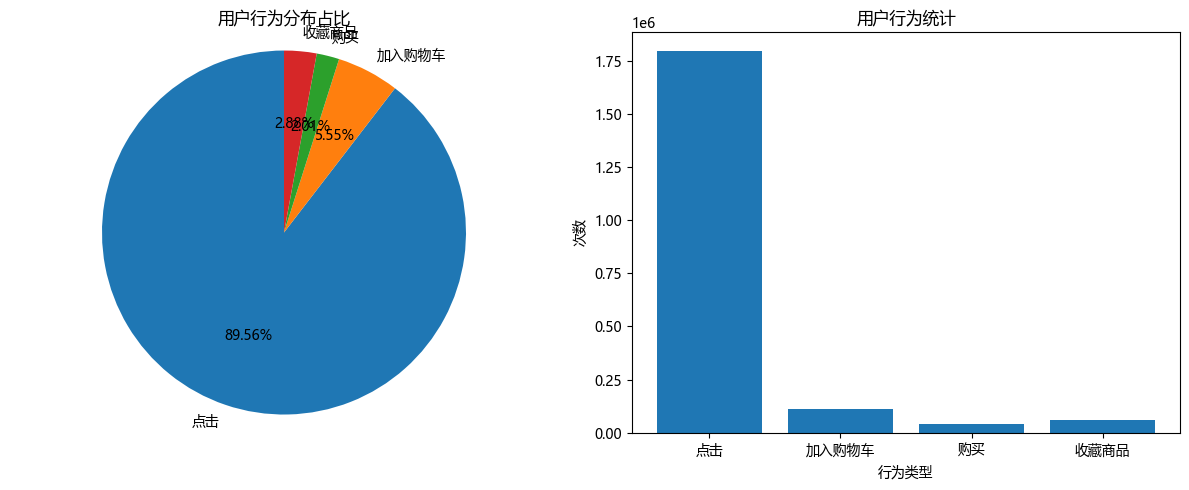

In [16]:
fig , axes = plt.subplots(1,2,figsize = (12,5)) #创建一行两列的子图
axes[0].pie(behavior_counts , labels= behavior_counts.index , autopct = '%.2f%%' , startangle = 90)
axes[0].axis('equal')
axes[0].set_title('用户行为分布占比')

axes[1].bar(behavior_counts.index , behavior_counts.values)
axes[1].set_title('用户行为统计')
axes[1].set_xlabel('行为类型')
axes[1].set_ylabel('次数')
axes[1].tick_params(axis = 'x' , rotation = 0)
plt.tight_layout()
plt.show()

**用户行为分布占比**：  
点击用户占比：89.57%  
加入购物车占比：5.55%  
购买用户占比：2.01%  
收藏用户占比：2.88%

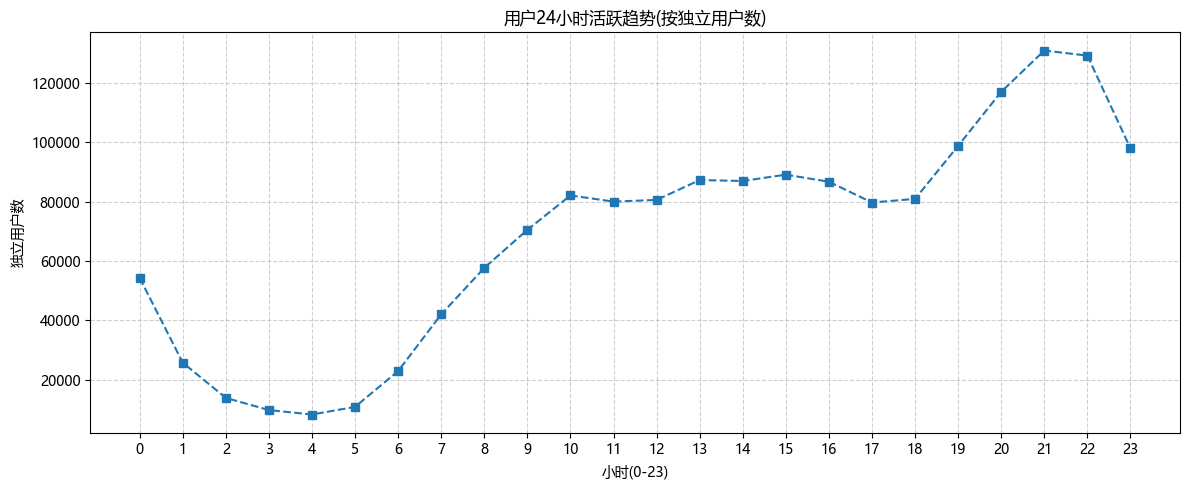

In [17]:
#用户小时活跃分布
hourly_act = cleaned_filter.groupby('整点')['用户id'].nunique()
plt.figure(figsize = (12 , 5))
plt.plot(hourly_act.index , hourly_act.values , marker = 's' , linestyle = '--')
plt.title('用户24小时活跃趋势(按独立用户数)')
plt.xlabel('小时(0-23)')
plt.ylabel('独立用户数')
plt.xticks(range(0 , 24))
plt.grid(True , linestyle = '--' , alpha = 0.6)
plt.tight_layout()
plt.show()

从独立用户数趋势来看，**活跃高峰出现在下午及晚间**（13-16点，21-22点），凌晨活跃度很低。

## 转化漏斗分析

In [18]:
#计算各环节独立用户数

#点击用户数
click_users = cleaned_filter[cleaned_filter['用户行为'] == '点击']['用户id'].nunique()

#计算加入购物车用户
carts_users = cleaned_filter[cleaned_filter['用户行为'] == '加入购物车']['用户id'].nunique()

#计算收藏商品用户
fav_users = cleaned_filter[cleaned_filter['用户行为'] == '收藏商品']['用户id'].nunique()

#计算购买商品用户
buy_users = cleaned_filter[cleaned_filter['用户行为'] == '购买']['用户id'].nunique()

#计算兴趣用户（至少有过一次加购或者收藏）
interest_users = cleaned_filter[(cleaned_filter['用户行为'] == '加入购物车') | (cleaned_filter['用户行为'] == '收藏商品')]['用户id'].nunique()

print(f'点击用户数:{click_users}')
print(f'商品加购用户数:{carts_users}')
print(f'商品收藏用户数:{fav_users}')
print(f'商品购买用户数:{buy_users}')
print(f'对商品感兴趣用户数:{interest_users}')

点击用户数:677575
商品加购用户数:96902
商品收藏用户数:47847
商品购买用户数:38423
对商品感兴趣用户数:140111


**构建漏斗**

In [19]:
stages = ['点击','兴趣(加购/收藏)','购买']
counts = [click_users , interest_users , buy_users]

for i,stage in enumerate(stages):
    print(f'{stage}:{counts[i]:,}人' , end = '')
    if i > 0:
         rate =  counts[i] / counts[i - 1] if counts[i -1] > 0 else 0
         print(f' → 转化率 {rate : .2%}')
    else:
         print()

点击:677,575人
兴趣(加购/收藏):140,111人 → 转化率  20.68%
购买:38,423人 → 转化率  27.42%


**绘制漏斗图**

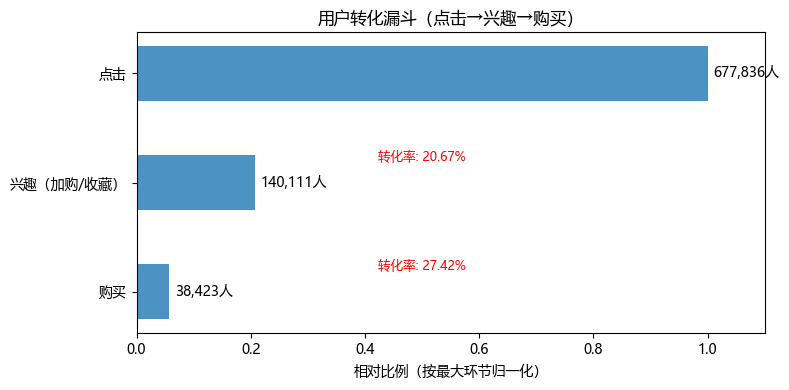

In [20]:
stages = ['点击', '兴趣（加购/收藏）', '购买']
counts = [677836, 140111, 38423]
max_count = max(counts)
widths = [c / max_count for c in counts]

fig, ax = plt.subplots(figsize=(8, 4))
y_pos = range(len(stages))

for i, (stage, w, count) in enumerate(zip(stages, widths, counts)):
    ax.barh(i, w, color='#1f77b4', height=0.5, alpha=0.8)
    ax.text(w + 0.01, i, f'{count:,}人', va='center', fontsize=10)

ax.set_yticks(y_pos)
ax.set_yticklabels(stages)
ax.set_xlim(0, 1.1)
ax.set_xlabel('相对比例（按最大环节归一化）')
ax.set_title('用户转化漏斗（点击→兴趣→购买）')

for i in range(1, len(counts)):
    rate = counts[i] / counts[i-1] if counts[i-1] > 0 else 0
    ax.text(0.5, i - 0.2, f'转化率: {rate:.2%}', ha='center', fontsize=9, color='red')

ax.invert_yaxis()
plt.tight_layout()
plt.show()

**漏斗图关键结论**
- **用户总量**:共有677,836名用户产生了点击行为，其中140,111名用户进一步表达了兴趣（加购或者收藏）,最终38,423名用户完成购买
- **转化瓶颈**:
1. 从“点击”到“兴趣”的转化率为**20.67%**，意味着接近80%的点击用户没有进行加购或收藏，这部分流失可能与商品吸引力不足、页面引导不清或价格因素有关
2. 从“兴趣”到“购买”转化率为**27.42%**，约72.6%的兴趣用户最终未完成支付购买。这通常指向购物车放弃、优惠不足或用户决策周期长等因素。
- **整体转化率**:点击 → 购买的最终转化率为**5.67%**（38423/677836），处于电商行业的典型区间（通常2%~10%），但仍存在较大优化空间

## RMF 用户分层

In [21]:
#计算参考日期
ref_date = cleaned_filter['发生时间'].max().normalize() + pd.DateOffset(days = 1)
print(f'参考日期：{ref_date}') 

#筛选出所有购买记录
buy_records = cleaned_filter[cleaned_filter['用户行为'] == '购买']

#计算每个用户的最近购买日期
user_last_buy = buy_records.groupby('用户id')['发生时间'].max()
print(f'有购买行为的用户数:{len(user_last_buy)}')

参考日期：2017-12-04 00:00:00
有购买行为的用户数:38423


计算 RFM

In [22]:
#R：距离最近一次购买天数（参考日期 - 最近购买日期）
R = (ref_date - user_last_buy).dt.days
R.name = 'Recency'

#F:每个用户的购买次数
F = buy_records.groupby('用户id').size()
F.name = 'Frequency'
#M:每个有用户的总行为次数（点击 + 加购 + 收藏 + 购买）
total_actions = cleaned_filter.groupby('用户id').size()
total_actions.name = 'Monetary'

#只保留购买行为的用户（R和F的索引）
M = total_actions[total_actions.index.isin(R.index)]

#合成 RFM
rfm = pd.concat([R , F, M], axis = 1)
print(rfm.head())

      Recency  Frequency  Monetary
用户id                              
62          0          1         2
80          8          1         4
107         6          1         1
190         6          1         6
192         5          2         5


In [23]:
#计算各指标的分位数（用户划分等级）
r_quantiles = rfm['Recency'].quantile([0.25 , 0.5 , 0.75])
f_quantiles = rfm['Frequency'].quantile([0.25 , 0.5 , 0.75])
m_quantiles = rfm['Monetary'].quantile([0.25 , 0.5 , 0.75])
def score_R(x):  #数值越小越好
    if x <= r_quantiles[0.25]:
        return 4
    elif x <= r_quantiles[0.5]:
        return 3
    elif x <= r_quantiles[0.75]:
        return 2
    else:
        return 1

def score_F(x): #数值越大越好
    if x >= f_quantiles[0.75]:
        return 4
    elif x >= f_quantiles[0.5]:
        return 3
    elif x >= f_quantiles[0.25]:
        return 2
    else:
        return 1

def score_M(x): #数值越大越好
    if x >= m_quantiles[0.75]:
        return 4
    elif x >= m_quantiles[0.5]:
        return 3
    elif x >= m_quantiles[0.25]:
        return 2
    else:
        return 1


rfm['R_score'] = rfm['Recency'].apply(score_R)
rfm['F_score'] = rfm['Frequency'].apply(score_F)
rfm['M_score'] = rfm['Monetary'].apply(score_M)

#总分(范围3~12)
rfm['Total_Score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

print(rfm[['R_score' , 'F_score' , 'M_score']].head())

      R_score  F_score  M_score
用户id                           
62          4        4        2
80          1        4        3
107         2        4        1
190         2        4        4
192         2        4        4


## 用户分层

In [24]:
def customer_segment(score):
    if score >= 10:
        return '高价值'
    elif score >= 7:
        return '中价值'
    else:
        return '低价值' 

rfm['Segment'] = rfm['Total_Score'].apply(customer_segment)

#统计各等级人数
seg_counts = rfm['Segment'].value_counts().reindex(['高价值' , '中价值' , '低价值'])
print(seg_counts)

Segment
高价值    17606
中价值    19332
低价值     1485
Name: count, dtype: int64


## 可视化RFM

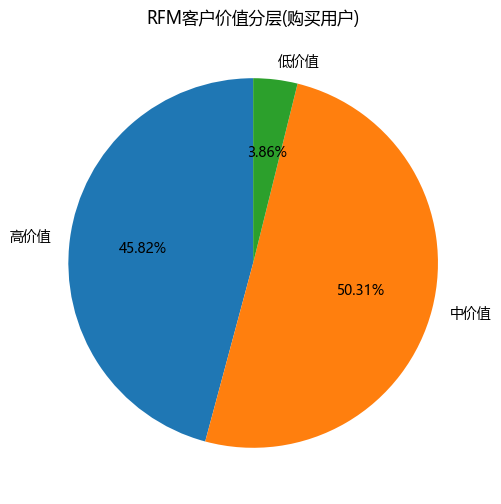

RFM结论:
总购买用户数:38423
高价值用户占比:45.82%
中价值用户占比:50.31%
低价值用户占比:3.86%


In [25]:
plt.figure(figsize = (6 , 6))
plt.pie(seg_counts , labels = seg_counts.index , autopct = '%1.2f%%' , startangle = 90)
plt.title('RFM客户价值分层(购买用户)')
plt.show()

print('RFM结论:')
print(f'总购买用户数:{len(rfm)}')
print(f'高价值用户占比:{seg_counts['高价值'] / len(rfm):.2%}')
print(f'中价值用户占比:{seg_counts['中价值'] / len(rfm):.2%}')
print(f'低价值用户占比:{seg_counts['低价值'] / len(rfm):.2%}')

高价值和中价值用户合计超过90%，说明购买用户普遍具有较高活跃度和消费能力。低价值用户极少，可能因为数据窗口短，新用户或一次性用户还未积累足够行为

## 品类分析

前10热门商品类目(按购买次数):
商品种类
1464116    686
2735466    672
4145813    641
4756105    613
2885642    593
4801426    547
982926     469
2640118    383
4159072    371
4357323    332
dtype: int64


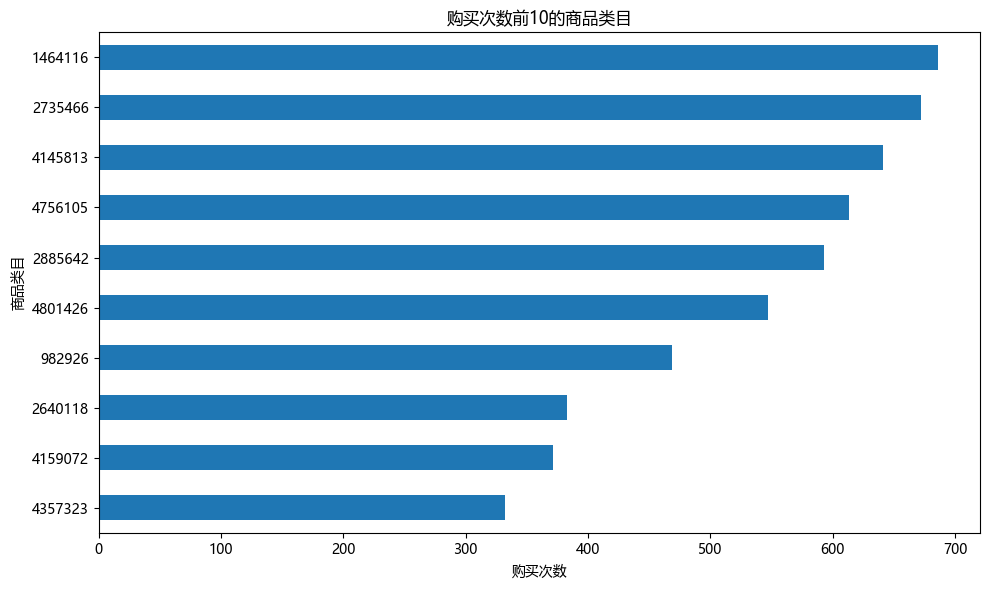

购买记录总数:40252
不同商品种类数:3334
前10种类目贡献占比:13.18%


In [26]:
#筛选购买记录
buy_only = cleaned_filter[cleaned_filter['用户行为'] == '购买']

#按商品种类分组，统计购买次数（销量）
category_sales = buy_only.groupby('商品种类').size().sort_values(ascending=False)

#取前10
top_10 = category_sales.head(10)
print('前10热门商品类目(按购买次数):')
print(top_10)

plt.figure(figsize = (10,6))
top_10.sort_values().plot(kind = 'barh')
plt.title('购买次数前10的商品类目')
plt.xlabel('购买次数')
plt.ylabel('商品类目')
plt.tight_layout()
plt.show()

print(f'购买记录总数:{len(buy_only)}')
print(f'不同商品种类数:{buy_only['商品种类'].nunique()}')
print(f'前10种类目贡献占比:{top_10.sum() / len(buy_only):.2%}')

前10热销商品(按购买次数):
商品id
3122135    27
3031354    21
3189426    15
3964583    15
1415828    15
4219087    14
1168232    12
2267309    12
5076029    11
3057515    11
dtype: int64


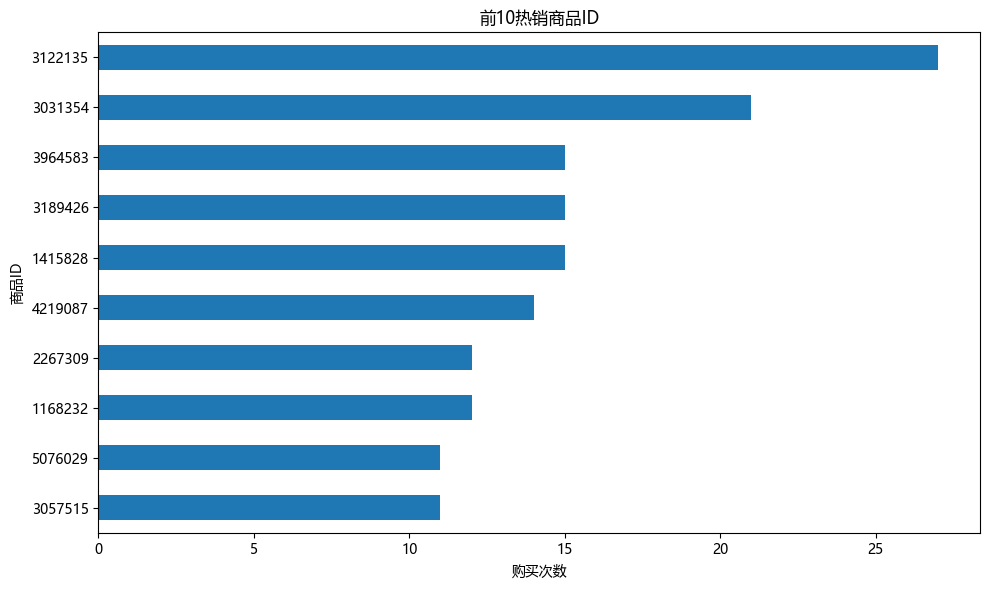

In [27]:
#按商品ID统计购买次数
item_sales = buy_only.groupby('商品id').size().sort_values(ascending=False)
top10_items = item_sales.head(10)
print('前10热销商品(按购买次数):')
print(top10_items)

plt.figure(figsize = (10 , 6))
top10_items.sort_values().plot(kind = 'barh')
plt.title('前10热销商品ID')
plt.xlabel('购买次数')
plt.ylabel('商品ID')
plt.tight_layout()
plt.show()

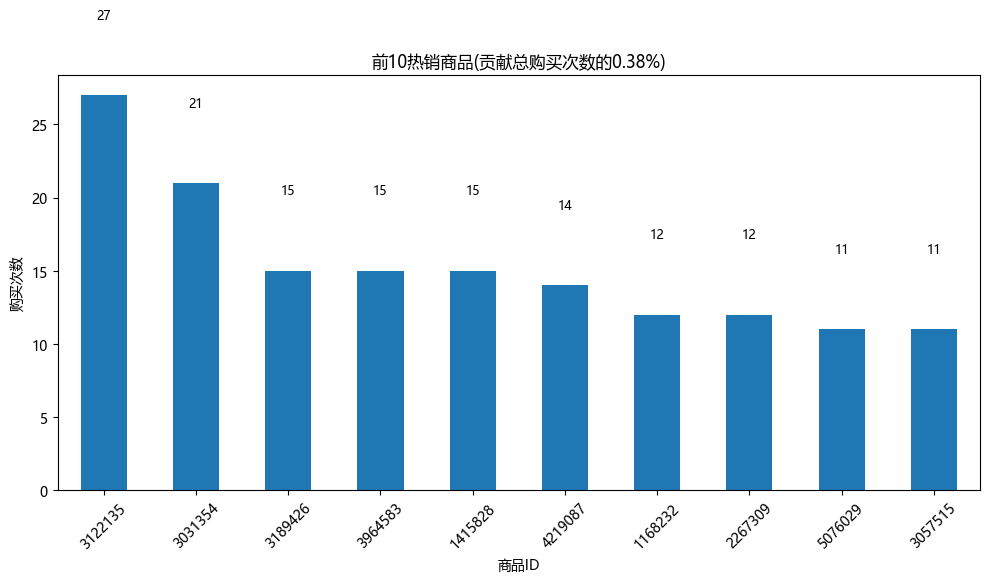

所有商品的总购买次数:40252
前10热销商品的购买次数:153
前10热销商品贡献度占比:0.38%


In [28]:
#前10热销产品占比 （原始数据没有金额  用购买次数作为衡量标准）

#1.统计每个商品的购买次数（只按购买行为）
item_buy_counts = cleaned_filter[cleaned_filter['用户行为'] == '购买'].groupby('商品id').size().sort_values(ascending=False)

#2.计算总购买次数和前10商品累计购买次数
total_buy = item_buy_counts.sum()
top10_buy = item_buy_counts.head(10)
top10_sum = top10_buy.sum()
top10_ratio = top10_sum / total_buy

#可视化
fig,ax = plt.subplots(figsize = (10 , 6))
top10_buy.plot(kind = 'bar' , ax = ax)
ax.set_title(f'前10热销商品(贡献总购买次数的{top10_ratio:.2%})')
ax.set_xlabel('商品ID')
ax.set_ylabel('购买次数')
ax.set_xticklabels(ax.get_xticklabels() , rotation = 45)

#柱子上方标注具体次数
for i, (idx, val) in enumerate(top10_buy.items()):
    ax.text(i, val + 5, f'{val}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print(f'所有商品的总购买次数:{total_buy:}')
print(f'前10热销商品的购买次数:{top10_sum}')
print(f'前10热销商品贡献度占比:{top10_ratio:.2%}')

由于分析的时间窗口仅覆盖2017年11月25日至12月3日（共8天），且每日购买次数约4000 ~ 5000 次 ，整体购买样本量有限，导致头部商品购买次数尚未拉开差距。在该时间段内，前10热销商品贡献了0.38%的购买次数，表明短期内用户购买行为较为分散，无绝对爆款。建议后续使用完整一年数据（或更长周期）重新评估商品集中度。

通过“收藏/加购”来发觉潜力产品

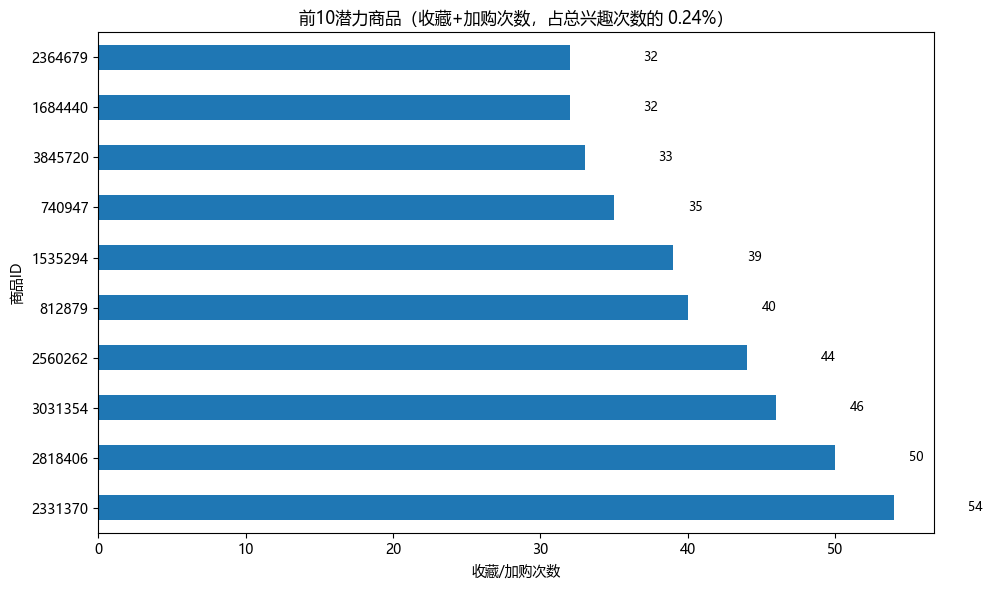

所有商品的收藏+加购总次数: 168,749
前10商品的兴趣次数合计: 405
前10商品贡献占比: 0.24%

前10商品明细:
商品id
2331370    54
2818406    50
3031354    46
2560262    44
812879     40
1535294    39
740947     35
3845720    33
1684440    32
2364679    32
dtype: int64


In [29]:
# 筛选收藏和加购行为
interest_data = cleaned_filter[cleaned_filter['用户行为'].isin(['收藏商品', '加入购物车'])]

# 按商品统计兴趣次数
item_interest_counts = interest_data.groupby('商品id').size().sort_values(ascending=False)

# 计算总兴趣次数和前10商品累计
total_interest = item_interest_counts.sum()
top10_interest = item_interest_counts.head(10)
top10_sum = top10_interest.sum()
top10_ratio = top10_sum / total_interest

fig, ax = plt.subplots(figsize=(10, 6))
top10_interest.sort_values().plot(kind='barh', ax=ax)
ax.set_title(f'前10潜力商品（收藏+加购次数，占总兴趣次数的 {top10_ratio:.2%}）')
ax.set_xlabel('收藏/加购次数')
ax.set_ylabel('商品ID')
ax.invert_yaxis()  # 让最高的显示在最上方

# 在条形末端标注具体次数
for i, (idx, val) in enumerate(top10_interest.sort_values().items()):
    ax.text(val + 5, i, f'{val}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"所有商品的收藏+加购总次数: {total_interest:,}")
print(f"前10商品的兴趣次数合计: {top10_sum:,}")
print(f"前10商品贡献占比: {top10_ratio:.2%}")
print("\n前10商品明细:")
print(top10_interest)

前10商品加购/收藏次数54 ~ 32次，占总数168,749的0.24%，同样分散。表明短期内用户兴趣未集中，但可以关注这些高兴趣商品作为未来促销的重点

## 运营策略优化建议   
1.**提高点击 → 兴趣转化(转化率仅20.67%)**  
  - 优化商品主图、标题和卖点，增加“限时折扣”、“热销标签”等刺激元素
  - 在商品详情页增加“收藏有礼”弹窗，或加购享优惠券（“如加购立减2元”）或“加购得积分”
  - 对首次点击用户，可马上推送2-4元不等的优惠券，刺激下单

2.**降低兴趣 → 购买流失(转化率仅27.42%)** 
 - 对加购/收藏超1小时未支付用户，发送站内下单提醒，或定向优惠券（满减或叠加优惠）
 - 对于超过24小时未支付的用户，加大优惠力度（如比加购时结算更优惠），同时发送“库存紧张”提醒
 - 加大用户活跃时段的商品曝光，活动推送

3.**用户分层运营**
 - 高价值用户（45.82%）：提供VIP专属折扣、新品优先购、双倍积分，提高忠实度
 - 中价值用户（50.31%）：推送“满额返现”、“任务满减”等活动，刺激提高用户单价或频次
 - 低价值用户（3.86%）：低成本唤醒，如发放小额优惠券或打折券，新品推送，若无效则沉默处理

4.**品类分析**
 - 购买前10商品贡献度占比仅0.38%，收藏/加购前10商品占比也仅0.24%。短期内无明显爆款，用户兴趣行为高度分散
 - 对兴趣前10的商品，定向发送优惠券并分析转化效果
 - 加大热销商品的报告多投放广告

5.**时间维度**
 - 用户活跃度高峰在下午及晚间，是对应运营资源投放的黄金窗口
 - 在高峰时段(如13-16点，21-22点)加大促销推送，客服排班和广告投放
 - 低活跃时段，可进行系统维护

**注:** 
   - 本次分析覆盖的有效购买数据仅为2017.11.25-12.3(仅9天)，可能导致结论缺乏稳定性，尤其商品集中度分析受限。
   - 由于原始数据中无金额字段，RFM中的M值用户行为总量代替，无法精准衡量用户消费力
 